In [1]:
# ======================================================
# BƯỚC 1: CÀI ĐẶT THƯ VIỆN
# ======================================================
!pip install pyvi
# Cài đặt phiên bản cũ ổn định hơn 
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

import pandas as pd
import numpy as np
import re
import os
import joblib
from pyvi import ViTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 5.1 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [2]:

# ======================================================
# BƯỚC 2: TỰ ĐỘNG TÌM FILE TRONG INPUT
# ======================================================
print("Đang quét thư mục Input để tìm file dữ liệu...")

train_df, dev_df, test_df = None, None, None

# Quét tất cả file trong /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        lower_name = filename.lower()
        
        # Logic tìm file dựa trên tên
        if 'train' in lower_name:
            print(f"-> Đã tìm thấy tập TRAIN: {path}")
            train_df = pd.read_csv(path)
        elif 'dev' in lower_name or 'val' in lower_name:
            print(f"-> Đã tìm thấy tập DEV/VALIDATION: {path}")
            dev_df = pd.read_csv(path)
        elif 'test' in lower_name:
            print(f"-> Đã tìm thấy tập TEST: {path}")
            test_df = pd.read_csv(path)
# Xử lý NaN và ép kiểu chuỗi cho CẢ Train và Test
train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
test_df['clean_text'] = test_df['clean_text'].fillna('').astype(str)

print(f"Số lượng mẫu Train: {len(train_df)}")
print(f"Số lượng mẫu Test:  {len(test_df)}")
# Kiểm tra xem đã load đủ chưa
if train_df is None or test_df is None:
    raise ValueError("LỖI: Không tìm thấy file 'train' hoặc 'test' trong Input. Bạn đã upload thành công chưa?")
else:
    print("Load dữ liệu thành công!")

Đang quét thư mục Input để tìm file dữ liệu...
-> Đã tìm thấy tập TRAIN: /kaggle/input/groupdata/train_cleand.csv
-> Đã tìm thấy tập TEST: /kaggle/input/groupdata/test_cleaned.csv
-> Đã tìm thấy tập DEV/VALIDATION: /kaggle/input/groupdata/dev_cleaned.csv
Số lượng mẫu Train: 64759
Số lượng mẫu Test:  6680
Load dữ liệu thành công!


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ==========================================================
# CẤU HÌNH VÀ CHẠY TF-IDF 
# ==========================================================
print("Đang thực hiện Trích xuất đặc trưng (Feature Extraction)...")

# 1. Khởi tạo mô hình TF-IDF
# Vì dữ liệu đã clean, ta dùng mặc định (tách từ theo khoảng trắng)
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,           # Bỏ qua từ xuất hiện < 5 lần
    max_df=0.9,         # Bỏ qua từ xuất hiện > 90%
    max_features=10000, # Lấy 10,000 từ quan trọng nhất
    ngram_range=(1, 2)  # Lấy từ đơn và cụm 2 từ
)

# 2. "Học" và biến đổi dữ liệu Train từ cột 'clean_text'
# .astype(str) để đảm bảo không lỗi nếu có dòng bị null
print("-> Đang fit và transform tập Train...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'].astype(str))

# 3. Chỉ biến đổi dữ liệu Test (Không fit lại)
print("-> Đang transform tập Test...")
X_test_tfidf = tfidf_vectorizer.transform(test_df['clean_text'].astype(str))

# 4. Xác định biến Nhãn (Target) dùng cột 'label_id'
y_train = train_df['label_id']
y_test = test_df['label_id']

# ==========================================================
# KIỂM TRA KẾT QUẢ
# ==========================================================

# 1. Xem kích thước ma trận
print(f"\nKích thước X_train: {X_train_tfidf.shape}")
print(f"Kích thước X_test:  {X_test_tfidf.shape}")
print(f"Kích thước y_train: {y_train.shape}")

# 2. Xem các từ vựng đã học
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nTổng số từ vựng (features) đã học: {len(feature_names)}")

# 3. Hàm soi trọng số (Dùng để kiểm tra xem máy học được gì từ clean_text)
def get_top_tfidf_features(row_index, top_n=5):
    row = X_train_tfidf[row_index]
    feature_index = row.indices
    tfidf_scores = row.data
    
    # Sắp xếp giảm dần theo trọng số
    sorted_indices = feature_index[np.argsort(tfidf_scores)[::-1]]
    top_features = [(feature_names[i], row[0, i]) for i in sorted_indices[:top_n]]
    return top_features

print("\n--- SOI THỬ MẪU ĐẦU TIÊN ---")
sample_idx = 0
print(f"Nội dung (clean_text): {train_df['clean_text'].iloc[sample_idx]}")
print(f"Nhãn (label_id): {train_df['label_id'].iloc[sample_idx]}")
print("Top từ khóa quan trọng:")
for word, score in get_top_tfidf_features(sample_idx):
    print(f" - {word}: {score:.4f}")

Đang thực hiện Trích xuất đặc trưng (Feature Extraction)...
-> Đang fit và transform tập Train...
-> Đang transform tập Test...

Kích thước X_train: (64759, 10000)
Kích thước X_test:  (6680, 10000)
Kích thước y_train: (64759,)

Tổng số từ vựng (features) đã học: 10000

--- SOI THỬ MẪU ĐẦU TIÊN ---
Nội dung (clean_text): địt_mẹ , con chó_đẻ này , làm_ăn như con cặc . biến hộ cái .
Nhãn (label_id): 1
Top từ khóa quan trọng:
 - này làm_ăn: 0.3528
 - hộ cái: 0.3471
 - địt_mẹ con: 0.3090
 - làm_ăn như: 0.2945
 - hộ: 0.2890


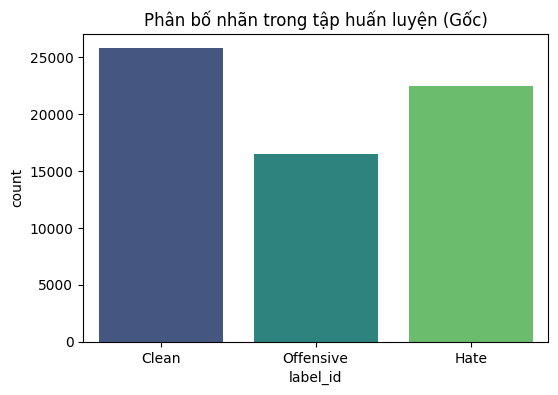

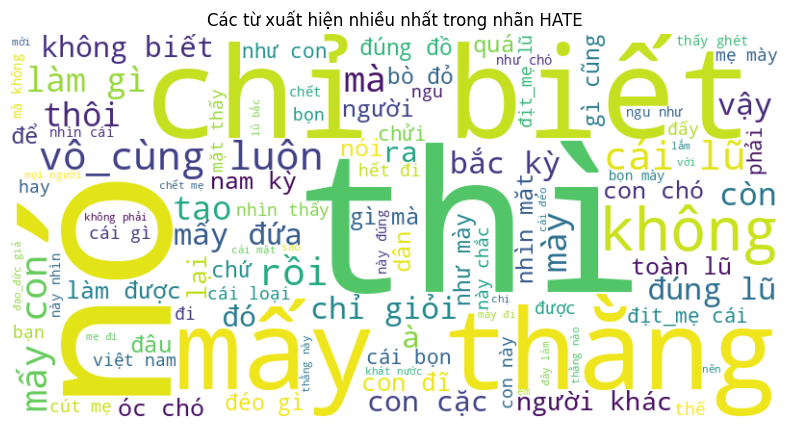

In [4]:
# ==========================================================
# KHÁM PHÁ DỮ LIỆU (EDA)
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Vẽ phân bố nhãn (Xem dữ liệu lệch thế nào)
plt.figure(figsize=(6, 4))
sns.countplot(x='label_id', data=train_df, palette='viridis')
plt.title('Phân bố nhãn trong tập huấn luyện (Gốc)')
plt.xticks([0, 1, 2], ['Clean', 'Offensive', 'Hate'])
plt.show()

# 2. Vẽ WordCloud (Xem từ nào hay xuất hiện trong nhóm Hate)
# Lọc ra các câu Hate
hate_comments = " ".join(train_df[train_df['label_id'] == 2]['clean_text'].astype(str))

# Tạo WordCloud
wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(hate_comments)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Các từ xuất hiện nhiều nhất trong nhãn HATE')
plt.show()

Đang huấn luyện mô hình LinearSVC...
-> Huấn luyện xong!

Đang dự đoán trên tập Test...

 ĐỘ CHÍNH XÁC (ACCURACY): 82.01%

--- CHI TIẾT TỪNG LỚP ---
               precision    recall  f1-score   support

    Clean (0)       0.94      0.88      0.91      5548
Offensive (1)       0.31      0.44      0.36       444
     Hate (2)       0.48      0.61      0.54       688

     accuracy                           0.82      6680
    macro avg       0.58      0.64      0.60      6680
 weighted avg       0.85      0.82      0.83      6680



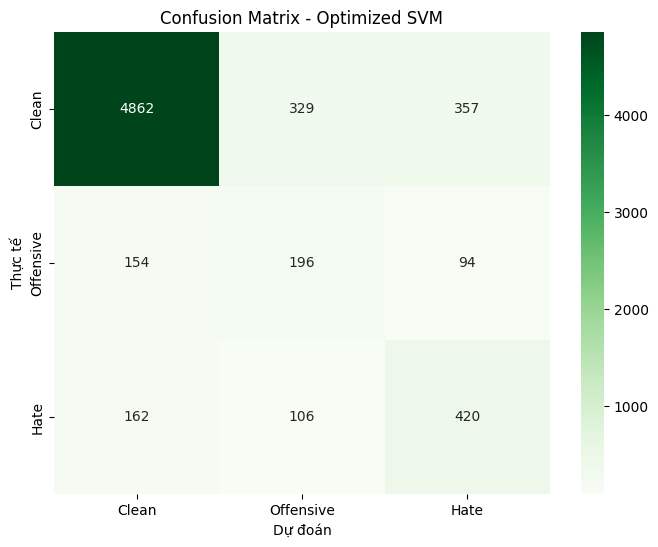


 Đã lưu model thành công! Có thể tải về file .pkl


In [5]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ==========================================================
# 1. HUẤN LUYỆN MÔ HÌNH (Sử dụng LinearSVC)
# ==========================================================
print("Đang huấn luyện mô hình LinearSVC...")

# 1. LinearSVC: Thuật toán tốt nhất cho phân loại văn bản (Text Classification)
# 2. class_weight='balanced': Tự động điều chỉnh trọng số để mô hình không thiên vị lớp nhiều dữ liệu
# 3. dual=False: Tối ưu tính toán khi số lượng mẫu lớn
svm_model = LinearSVC(
    C=1.0, 
    class_weight='balanced', 
    dual=False, 
    random_state=42,
    max_iter=3000
)

# Sử dụng X_train_tfidf và y_train đã tạo ở Cell trên
svm_model.fit(X_train_tfidf, y_train)
print("-> Huấn luyện xong!")

# ==========================================================
# 2. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================================
print("\nĐang dự đoán trên tập Test...")

# Sử dụng X_test_tfidf và y_test đã tạo ở Cell trên
y_pred = svm_model.predict(X_test_tfidf)

# Tính Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n ĐỘ CHÍNH XÁC (ACCURACY): {acc*100:.2f}%")

# In báo cáo chi tiết (Precision, Recall, F1-Score)
print("\n--- CHI TIẾT TỪNG LỚP ---")
print(classification_report(y_test, y_pred, target_names=['Clean (0)', 'Offensive (1)', 'Hate (2)']))

# ==========================================================
# 3. VẼ CONFUSION MATRIX (Để xem mô hình nhầm lẫn ở đâu)
# ==========================================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Clean', 'Offensive', 'Hate'],
            yticklabels=['Clean', 'Offensive', 'Hate'])
plt.title('Confusion Matrix - Optimized SVM')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# ==========================================================
# 4. LƯU MODEL ĐỂ DÙNG SAU
# ==========================================================
# Lưu cả model và bộ từ điển tfidf (ở cell trên)
joblib.dump(svm_model, 'final_svm_model.pkl')
joblib.dump(tfidf_vectorizer, 'final_tfidf.pkl')
print("\n Đã lưu model thành công! Có thể tải về file .pkl")

Đang tính toán Learning Curve...


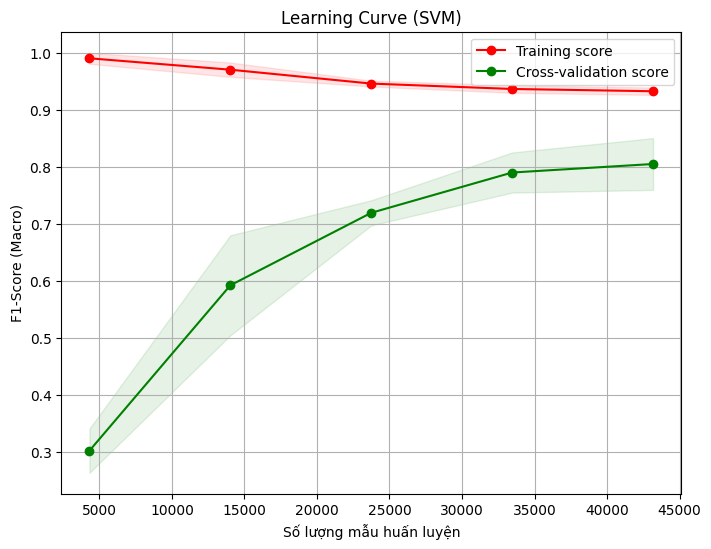

In [7]:
# ==========================================================
# VẼ BIỂU ĐỒ LEARNING CURVE CHO SVM
# ==========================================================
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("Đang tính toán Learning Curve...")

# Định nghĩa hàm vẽ
def plot_learning_curve(estimator, title, X, y, cv=3, n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), # Chia thành 5 mốc dữ liệu
        scoring='f1_macro'
    )
    
    # Tính trung bình và độ lệch chuẩn
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("F1-Score (Macro)")
    plt.grid()

    # Vẽ vùng dao động (Standard Deviation)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Vẽ đường trung bình
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# Chạy hàm vẽ với mô hình SVM hiện tại
# Lưu ý: Ta dùng dữ liệu gốc vector hóa để demo xu hướng
plot_learning_curve(svm_model, "Learning Curve (SVM)", X_train_tfidf, y_train, cv=3)

In [32]:
# ==========================================================
# TRÍCH XUẤT CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI
# ==========================================================
import pandas as pd

# Tạo DataFrame so sánh
results_df = pd.DataFrame({
    'Noi_dung': test_df['clean_text'],         # Nội dung gốc để dễ đọc
    'Thuc_te': y_test,
    'Du_doan': y_pred
})

# Lọc các trường hợp SAI (Thực tế != Dự đoán)
wrong_predictions = results_df[results_df['Thuc_te'] != results_df['Du_doan']]

print(f"Tổng số câu sai: {len(wrong_predictions)} / {len(results_df)}")

# Định nghĩa map nhãn để in cho dễ hiểu
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

print("\n=== VÍ DỤ 1: Thực tế là CLEAN nhưng bị đoán nhầm là HATE (False Positive) ===")
# Lỗi này làm oan người dùng
fp_cases = wrong_predictions[(wrong_predictions['Thuc_te'] == 0) & (wrong_predictions['Du_doan'] == 2)]
if not fp_cases.empty:
    for i in range(min(3, len(fp_cases))):
        row = fp_cases.iloc[i]
        print(f"- Câu: {row['Noi_dung']}")
        print(f"  -> Máy nghĩ là: {label_map[row['Du_doan']]}\n")

print("\n=== VÍ DỤ 2: Thực tế là HATE nhưng bị đoán nhầm là CLEAN (False Negative) ===")
# Lỗi này để lọt bình luận độc hại
fn_cases = wrong_predictions[(wrong_predictions['Thuc_te'] == 2) & (wrong_predictions['Du_doan'] == 0)]
if not fn_cases.empty:
    for i in range(min(3, len(fn_cases))):
        row = fn_cases.iloc[i]
        print(f"- Câu: {row['Noi_dung']}")
        print(f"  -> Máy nghĩ là: {label_map[row['Du_doan']]}\n")

print("\n=== VÍ DỤ 3: Nhầm lẫn giữa OFFENSIVE và HATE ===")
# Lỗi khó phân biệt biên giới
ambiguous_cases = wrong_predictions[(wrong_predictions['Thuc_te'] == 1) & (wrong_predictions['Du_doan'] == 2)]
if not ambiguous_cases.empty:
    for i in range(min(3, len(ambiguous_cases))):
        row = ambiguous_cases.iloc[i]
        print(f"- Câu: {row['Noi_dung']}")
        print(f"  -> Thực tế: {label_map[row['Thuc_te']]} | Máy đoán: {label_map[row['Du_doan']]}\n")

Tổng số câu sai: 1175 / 6680

=== VÍ DỤ 1: Thực tế là CLEAN nhưng bị đoán nhầm là HATE (False Positive) ===
- Câu: the nay ma chi phat gay roi trat tu cong cong thoi a dung la dan minh
  -> Máy nghĩ là: Hate

- Câu: mua em hộp bcs mĩ sài oai : ) )
  -> Máy nghĩ là: Hate

- Câu: hang luc nao cung phai chuan nhu hom nay giao toi day_nhe
  -> Máy nghĩ là: Hate


=== VÍ DỤ 2: Thực tế là HATE nhưng bị đoán nhầm là CLEAN (False Negative) ===
- Câu: đề_nghị 17 , 22,23,32 đến phà vài hơi vào mẹt tk này để nó đi cách_ly thế_giới hẳn đi .
  -> Máy nghĩ là: Clean

- Câu: đem ra bắn ngay cái thể_loại ấy
  -> Máy nghĩ là: Clean

- Câu: bàn_tay em đẹp quá . nhìn chị đàn_bà mà xấu quá . .
  -> Máy nghĩ là: Clean


=== VÍ DỤ 3: Nhầm lẫn giữa OFFENSIVE và HATE ===
- Câu: không nói thì tự_kiêu , nói thì lại tự_ái chứ í thức thế ai mà chịu nổi 😡
  -> Thực tế: Offensive | Máy đoán: Hate

- Câu: một phút bóc đồng_bằng cả đời bóc cức 😂
  -> Thực tế: Offensive | Máy đoán: Hate

- Câu: cái mặt con bò biểu_cảm

In [33]:
# ==========================================================
# XUẤT FILE PHÂN TÍCH LỖI
# ==========================================================
import pandas as pd

# 1. Tạo bản sao để không ảnh hưởng dữ liệu gốc
wrong_df = test_df.copy()

# 2. Thêm cột dự đoán vào ( y_pred đã được tạo từ bước Predict trước đó)
wrong_df['predicted'] = y_pred

# 3. Lọc ra những dòng mà Nhãn thực tế KHÁC Nhãn dự đoán
wrong_df = wrong_df[wrong_df['label_id'] != wrong_df['predicted']]

# 4. Map nhãn số sang chữ cho dễ đọc
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

# Sửa 'label' -> 'label_id'
wrong_df['label_name'] = wrong_df['label_id'].map(label_map)
wrong_df['pred_name'] = wrong_df['predicted'].map(label_map)

# 5. Lưu ra CSV để tải về làm báo cáo
wrong_df[['clean_text', 'label_name', 'pred_name']].to_csv('error_analysis.csv', index=False, encoding='utf-8-sig')

print(f"Đã lưu {len(wrong_df)} câu dự đoán sai vào file 'error_analysis.csv'.")
print("Bạn hãy tải file này về để chọn ví dụ đưa vào báo cáo.")
print("\nXem thử 3 dòng sai đầu tiên:")
print(wrong_df[['clean_text', 'label_name', 'pred_name']].head(3))

Đã lưu 1175 câu dự đoán sai vào file 'error_analysis.csv'.
Bạn hãy tải file này về để chọn ví dụ đưa vào báo cáo.

Xem thử 3 dòng sai đầu tiên:
                                          clean_text label_name  pred_name
0                     đừng cố biện_minh = ) choi lon      Clean  Offensive
1                   haizz . nthe này thì dân khổ quá  Offensive      Clean
2  the nay ma chi phat gay roi trat tu cong cong ...      Clean       Hate


# **ALL-IN-ONE VERSION**

```python
# ======================================================
# BƯỚC 1: CÀI ĐẶT THƯ VIỆN
# ======================================================
!pip install pyvi
# Cài đặt phiên bản cũ ổn định hơn 
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

import pandas as pd
import numpy as np
import re
import os
import joblib
from pyvi import ViTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# ======================================================
# BƯỚC 2: TỰ ĐỘNG TÌM FILE TRONG INPUT
# ======================================================
print("Đang quét thư mục Input để tìm file dữ liệu...")

train_df, dev_df, test_df = None, None, None

# Quét tất cả file trong /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        lower_name = filename.lower()
        
        # Logic tìm file dựa trên tên
        if 'train' in lower_name:
            print(f"-> Đã tìm thấy tập TRAIN: {path}")
            train_df = pd.read_csv(path)
        elif 'dev' in lower_name or 'val' in lower_name:
            print(f"-> Đã tìm thấy tập DEV/VALIDATION: {path}")
            dev_df = pd.read_csv(path)
        elif 'test' in lower_name:
            print(f"-> Đã tìm thấy tập TEST: {path}")
            test_df = pd.read_csv(path)
# Xử lý NaN và ép kiểu chuỗi cho CẢ Train và Test
train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
test_df['clean_text'] = test_df['clean_text'].fillna('').astype(str)

print(f"Số lượng mẫu Train: {len(train_df)}")
print(f"Số lượng mẫu Test:  {len(test_df)}")
# Kiểm tra xem đã load đủ chưa
if train_df is None or test_df is None:
    raise ValueError("LỖI: Không tìm thấy file 'train' hoặc 'test' trong Input. Bạn đã upload thành công chưa?")
else:
    print("Load dữ liệu thành công!")

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ==========================================================
# CẤU HÌNH VÀ CHẠY TF-IDF 
# ==========================================================
print("Đang thực hiện Trích xuất đặc trưng (Feature Extraction)...")

# 1. Khởi tạo mô hình TF-IDF
# Vì dữ liệu đã clean, ta dùng mặc định (tách từ theo khoảng trắng)
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,           # Bỏ qua từ xuất hiện < 5 lần
    max_df=0.9,         # Bỏ qua từ xuất hiện > 90%
    max_features=10000, # Lấy 10,000 từ quan trọng nhất
    ngram_range=(1, 2)  # Lấy từ đơn và cụm 2 từ
)

# 2. "Học" và biến đổi dữ liệu Train từ cột 'clean_text'
# .astype(str) để đảm bảo không lỗi nếu có dòng bị null
print("-> Đang fit và transform tập Train...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'].astype(str))

# 3. Chỉ biến đổi dữ liệu Test (Không fit lại)
print("-> Đang transform tập Test...")
X_test_tfidf = tfidf_vectorizer.transform(test_df['clean_text'].astype(str))

# 4. Xác định biến Nhãn (Target) dùng cột 'label_id'
y_train = train_df['label_id']
y_test = test_df['label_id']

# ==========================================================
# KIỂM TRA KẾT QUẢ
# ==========================================================

# 1. Xem kích thước ma trận
print(f"\nKích thước X_train: {X_train_tfidf.shape}")
print(f"Kích thước X_test:  {X_test_tfidf.shape}")
print(f"Kích thước y_train: {y_train.shape}")

# 2. Xem các từ vựng đã học
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nTổng số từ vựng (features) đã học: {len(feature_names)}")

# 3. Hàm soi trọng số (Dùng để kiểm tra xem máy học được gì từ clean_text)
def get_top_tfidf_features(row_index, top_n=5):
    row = X_train_tfidf[row_index]
    feature_index = row.indices
    tfidf_scores = row.data
    
    # Sắp xếp giảm dần theo trọng số
    sorted_indices = feature_index[np.argsort(tfidf_scores)[::-1]]
    top_features = [(feature_names[i], row[0, i]) for i in sorted_indices[:top_n]]
    return top_features

print("\n--- SOI THỬ MẪU ĐẦU TIÊN ---")
sample_idx = 0
print(f"Nội dung (clean_text): {train_df['clean_text'].iloc[sample_idx]}")
print(f"Nhãn (label_id): {train_df['label_id'].iloc[sample_idx]}")
print("Top từ khóa quan trọng:")
for word, score in get_top_tfidf_features(sample_idx):
    print(f" - {word}: {score:.4f}")

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ==========================================================
# 1. HUẤN LUYỆN MÔ HÌNH (Sử dụng LinearSVC)
# ==========================================================
print("Đang huấn luyện mô hình LinearSVC...")

# 1. LinearSVC: Thuật toán tốt nhất cho phân loại văn bản (Text Classification)
# 2. class_weight='balanced': Tự động điều chỉnh trọng số để mô hình không thiên vị lớp nhiều dữ liệu
# 3. dual=False: Tối ưu tính toán khi số lượng mẫu lớn
svm_model = LinearSVC(
    C=1.0, 
    class_weight='balanced', 
    dual=False, 
    random_state=42,
    max_iter=3000
)

# Sử dụng X_train_tfidf và y_train đã tạo ở Cell trên
svm_model.fit(X_train_tfidf, y_train)
print("-> Huấn luyện xong!")

# ==========================================================
# 2. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================================
print("\nĐang dự đoán trên tập Test...")

# Sử dụng X_test_tfidf và y_test đã tạo ở Cell trên
y_pred = svm_model.predict(X_test_tfidf)

# Tính Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n ĐỘ CHÍNH XÁC (ACCURACY): {acc*100:.2f}%")

# In báo cáo chi tiết (Precision, Recall, F1-Score)
print("\n--- CHI TIẾT TỪNG LỚP ---")
print(classification_report(y_test, y_pred, target_names=['Clean (0)', 'Offensive (1)', 'Hate (2)']))

# ==========================================================
# 3. VẼ CONFUSION MATRIX (Để xem mô hình nhầm lẫn ở đâu)
# ==========================================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Clean', 'Offensive', 'Hate'],
            yticklabels=['Clean', 'Offensive', 'Hate'])
plt.title('Confusion Matrix - Optimized SVM')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# ==========================================================
# 4. LƯU MODEL ĐỂ DÙNG SAU
# ==========================================================
# Lưu cả model và bộ từ điển tfidf (ở cell trên)
joblib.dump(svm_model, 'final_svm_model.pkl')
joblib.dump(tfidf_vectorizer, 'final_tfidf.pkl')
print("\n Đã lưu model thành công! Có thể tải về file .pkl")

# ==========================================================
# VẼ BIỂU ĐỒ LEARNING CURVE CHO SVM
# ==========================================================
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("Đang tính toán Learning Curve...")

# Định nghĩa hàm vẽ
def plot_learning_curve(estimator, title, X, y, cv=3, n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), # Chia thành 5 mốc dữ liệu
        scoring='f1_macro'
    )
    
    # Tính trung bình và độ lệch chuẩn
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("F1-Score (Macro)")
    plt.grid()

    # Vẽ vùng dao động (Standard Deviation)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Vẽ đường trung bình
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# Chạy hàm vẽ với mô hình SVM hiện tại
# Lưu ý: Ta dùng dữ liệu gốc vector hóa để demo xu hướng
plot_learning_curve(svm_fast, "Learning Curve (SVM)", X_train_tfidf, y_train, cv=3)

# ==========================================================
# XUẤT FILE PHÂN TÍCH LỖI
# ==========================================================
import pandas as pd

# 1. Tạo bản sao để không ảnh hưởng dữ liệu gốc
wrong_df = test_df.copy()

# 2. Thêm cột dự đoán vào ( y_pred đã được tạo từ bước Predict trước đó)
wrong_df['predicted'] = y_pred

# 3. Lọc ra những dòng mà Nhãn thực tế KHÁC Nhãn dự đoán
wrong_df = wrong_df[wrong_df['label_id'] != wrong_df['predicted']]

# 4. Map nhãn số sang chữ cho dễ đọc
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

# Sửa 'label' -> 'label_id'
wrong_df['label_name'] = wrong_df['label_id'].map(label_map)
wrong_df['pred_name'] = wrong_df['predicted'].map(label_map)

# 5. Lưu ra CSV để tải về làm báo cáo
wrong_df[['clean_text', 'label_name', 'pred_name']].to_csv('error_analysis.csv', index=False, encoding='utf-8-sig')

print(f"Đã lưu {len(wrong_df)} câu dự đoán sai vào file 'error_analysis.csv'.")
print("Bạn hãy tải file này về để chọn ví dụ đưa vào báo cáo.")
print("\nXem thử 3 dòng sai đầu tiên:")
print(wrong_df[['clean_text', 'label_name', 'pred_name']].head(3))
```